# NEOFC - Physiological association analyses in YRSP dataset

In [1]:
from pathlib import Path 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sn

from scipy.stats import spearmanr
from pingouin import partial_corr
from statsmodels.formula import api as smf

from utils import load_neofc_stats

# working directory
wd = Path.cwd() 
print(wd)

# general vars
from utils import (REF_GROUPS_COLORS, REF_NAMES_PET, MEASURES_NICE, REF_MATH_NAMES)

colors = REF_GROUPS_COLORS[1:]

/Users/llotter/projects/mapfc


## Data

In [2]:
parc_cx = "Schaefer200"
parc_wb = "Schaefer200Subcortical"
parcs = [parc_cx, parc_wb]

### HCP-YA

In [3]:
# NEOFC stats MRI: average by direction -> we will have to average the data below by direction as well
neofc_ya_mri_indivstats = load_neofc_stats("hcp_ya_mri", parcs, dset="pet", level="individual", stats="auc")
#display(neofc_ya_mri_indivstats.head())

# Physio data (HRV)
physio_ya = pd.read_csv(wd / "data_deriv" / "pheno" / "hcp_ya" / "physio" / "hcp_ya_physio_proc.csv", index_col=[0,1,2])
physio_ya = physio_ya.reset_index().assign(run = lambda x: x["ses"].str[-1].astype(int)).set_index(["sub", "run", "dir"])
physio_ya = physio_ya.drop(columns=["ses"]).groupby(["sub", "run"]).mean()
#display(physio_ya.head())

# Mean FD
qc_ya = pd.read_table(wd / "data_source" / "timeseries" / "hcp_ya_mri" / "linc_qc.tsv")
qc_ya = qc_ya[["sub", "run", "dir", "mean_fd"]].set_index(["sub", "run", "dir"])
qc_ya = qc_ya.groupby(["sub", "run"]).mean()
#display(qc_ya.head())

# Global correlation
gc_ya_mri = (
    pd.concat([pd.read_csv(wd / "data_deriv" / "connectomes" / "hcp_ya_mri" / f"parc-{parc}_sac.csv").assign(parc=parc)
               for parc in parcs], 
              axis=0)
    .assign(sub=lambda x: x["sub"].str.split("-").str[1].astype(int))
    .set_index(["parc", "measure", "sub", "run"])
    .loc[:, "gc"]
)
#display(gc_ya_mri.head())

# Age, sex, bmi
pheno_ya = pd.read_csv(wd / "data_deriv" / "pheno" / "hcp_ya" / "hcp_ya_pheno.csv", index_col=0)[["sex", "age", "bmi"]]
# sex to numeric
pheno_ya["sex"] = pheno_ya["sex"].map({"M": 0, "F": 1})
#display(pheno_ya.head())

# Merge MRI
physio_ya_hrv = (
    neofc_ya_mri_indivstats
    .loc[parcs, :, "all", :, "original", :, "val"] 
    .reset_index()
    .assign(
        #run=lambda x: x["run"].str.split(",").str[0].map({"('1'": 1, "('2'": 2}),
        sub=lambda x: x["id"].str.split("-").str[1].astype(int)
    )
    .set_index(["parc", "measure", "stat", "sub", "run"])
    .merge(qc_ya, left_on=["sub", "run"], right_index=True, how="inner")
    .merge(pheno_ya, left_on="sub", right_index=True, how="inner")
    .merge(physio_ya, left_on=["sub", "run"], right_index=True, how="inner")
    .merge(gc_ya_mri, left_on=["parc", "measure", "sub", "run"], right_index=True, how="inner")
)
print(f"{physio_ya_hrv.index.get_level_values('sub').nunique()} subjects "
      f"with {physio_ya_hrv.loc[parc_cx, 'pearson', 'auc', :, :].shape[0]} sessions")
#display(physio_ya_hrv.head())

Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ya_mri/parc-..._dset-pet_stat-..._individual.csv.gz
94 subjects with 187 sessions


### YRSP

In [4]:
# Mapconn stats
neofc_yrsp_indivstats = load_neofc_stats("yrsp", parcs, level="individual", stats="auc")
display(neofc_yrsp_indivstats.head())

# Physio data (Pupil diameter - PUI)
physio_yrsp_pui = pd.read_csv(wd / "data_deriv" / "pheno" / "yrsp" / "pupil_size_proc_pui.csv", index_col=[0,1])
physio_yrsp_pui[["lf_s", "lf_r", "hf_p"]] = physio_yrsp_pui[["lf_s", "lf_r", "hf_p"]].transform("log")
display(physio_yrsp_pui.head())

# Age and sex not available for YRSP

# Mean FD
qc_yrsp = pd.read_table(wd / "data_source" / "timeseries" / "yrsp" / "linc_qc.tsv")
qc_yrsp = qc_yrsp[["sub", "run", "mean_fd"]].assign(sub=lambda x: "sub-" + x["sub"]).set_index(["sub", "run"])
display(qc_yrsp.head())

# Global correlation
gc_yrsp = (
    pd.concat([pd.read_csv(wd / "data_deriv" / "connectomes" / "yrsp" / f"parc-{parc}_sac.csv").assign(parc=parc)
               for parc in parcs], 
              axis=0)
    #.assign(sub=lambda x: x["sub"].str.split("-").str[1].astype(int))
    .set_index(["parc", "measure", "sub", "run"])
    .loc[:, "gc"]
)
display(gc_yrsp.head())

# Merge
physio_yrsp_pui = (
    neofc_yrsp_indivstats
    .loc[(parcs, slice(None), "all", slice(None), "original", slice(None), "val")]
    .reset_index()
    .rename(columns={"id": "sub"})
    .set_index(["parc", "measure", "stat", "sub", "run"])
    .merge(qc_yrsp, left_on=["sub", "run"], right_index=True, how="inner")
    .merge(physio_yrsp_pui, left_on=["sub", "run"], right_index=True, how="inner")
    .merge(gc_yrsp, left_on=["parc", "measure", "sub", "run"], right_index=True, how="inner")
)
print(f"{physio_yrsp_pui.index.get_level_values('sub').nunique()} subjects with "
      f"{physio_yrsp_pui.loc[parc_cx, 'pearson', 'auc', :, :, :].shape[0]} sessions")
physio_yrsp_pui

Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/yrsp/parc-..._stat-..._individual.csv.gz


5HT1a  \
parc        measure connections run metric   stat variable id                     
Schaefer200 pearson all         1   original auc  val      sub-pa1372  0.008812   
                                                           sub-pa1387  0.014889   
                                                           sub-pa1416  0.001489   
                                                           sub-pa1560 -0.001050   
                                                           sub-pa1582  0.030460   

                                                                          5HT1b  \
parc        measure connections run metric   stat variable id                     
Schaefer200 pearson all         1   original auc  val      sub-pa1372  0.019752   
                                                           sub-pa1387  0.042009   
                                                           sub-pa1416  0.023256   
                                                           sub-pa1560  0.029600   
                                                           sub-pa1582  0.023852   

                                                                          5HT2a  \
parc        measure connections run metric   stat variable id                     
Schaefer200 pearson all         1   original auc  val      sub-pa1372  0.020832   
                                                           sub-pa1387  0.047013   
                                                           sub-pa1416  0.017927   
                                                           sub-pa1560  0.009493   
                                                           sub-pa1582  0.019360   

                                                                           5HT4  \
parc        measure connections run metric   stat variable id                     
Schaefer200 pearson all         1   original auc  val      sub-pa1372  0.018689   
                                                           sub-pa1387  0.032184   
                                                           sub-pa1416  0.010324   
                                                           sub-pa1560  0.001879   
                                                           sub-pa1582  0.018242   

                                                                           5HT6  \
parc        measure connections run metric   stat variable id                     
Schaefer200 pearson all         1   original auc  val      sub-pa1372  0.004066   
                                                           sub-pa1387  0.018449   
                                                           sub-pa1416  0.006375   
                                                           sub-pa1560  0.011269   
                                                           sub-pa1582  0.010127   

                                                                           5HTT  \
parc        measure connections run metric   stat variable id                     
Schaefer200 pearson all         1   original auc  val      sub-pa1372  0.043622   
                                                           sub-pa1387  0.047591   
                                                           sub-pa1416  0.040488   
                                                           sub-pa1560  0.039849   
                                                           sub-pa1582  0.042713   

                                                                           A4B2  \
parc        measure connections run metric   stat variable id                     
Schaefer200 pearson all         1   original auc  val      sub-pa1372  0.006438   
                                                           sub-pa1387  0.039515   
                                                           sub-pa1416  0.013799   
                                                           sub-pa1560 -0.000112   
                                                           sub-pa1582  0.012929   



prop_good  max_gap   mad_vel     qc       pui      lf_s  \
sub        run                                                            
sub-pa1372 1         1.00      1.0  1.337988   True  2.393952  1.564689   
           2         1.00      0.0  1.295745   True  2.347219  1.531653   
sub-pa1387 1         0.71     38.0  2.743471  False  4.991361       NaN   
           2         1.00      3.0  1.387382   True  3.165966  2.812437   
sub-pa1416 1         1.00      1.0  1.276937   True  2.385295  2.115881   

                    lf_r      hf_p  
sub        run                      
sub-pa1372 1    1.303631 -0.252416  
           2    0.877113 -0.736043  
sub-pa1387 1         NaN       NaN  
           2    1.705598 -0.685663  
sub-pa1416 1    1.283838 -0.773357

mean_fd
sub        run          
sub-pa1372 1    0.152312
           2    0.098428
sub-pa1387 1    0.168287
           2    0.138856
sub-pa1393 1    0.203768

parc         measure  sub         run
Schaefer200  pearson  sub-pa1372  1      0.012886
                                  2      0.010460
                      sub-pa1387  1      0.023514
                                  2      0.018524
                      sub-pa1416  1      0.020752
Name: gc, dtype: float64

26 subjects with 52 sessions


connections    metric  \
parc                   measure stat sub        run                         
Schaefer200            pearson auc  sub-pa1372 1           all  original   
                                    sub-pa1387 1           all  original   
                                    sub-pa1416 1           all  original   
                                    sub-pa1560 1           all  original   
                                    sub-pa1582 1           all  original   
...                                                        ...       ...   
Schaefer200Subcortical pearson auc  sub-pa2213 2           all  original   
                                    sub-pa2216 2           all  original   
                                    sub-pa2220 2           all  original   
                                    sub-pa2221 2           all  original   
                                    sub-pa2226 2           all  original   

                                                   variable     5HT1a  \
parc                   measure stat sub        run                      
Schaefer200            pearson auc  sub-pa1372 1        val  0.008812   
                                    sub-pa1387 1        val  0.014889   
                                    sub-pa1416 1        val  0.001489   
                                    sub-pa1560 1        val -0.001050   
                                    sub-pa1582 1        val  0.030460   
...                                                     ...       ...   
Schaefer200Subcortical pearson auc  sub-pa2213 2        val  0.024739   
                                    sub-pa2216 2        val  0.039588   
                                    sub-pa2220 2        val  0.009755   
                                    sub-pa2221 2        val  0.017646   
                                    sub-pa2226 2        val  0.019806   

                                                       5HT1b     5HT2a  \
parc                   measure stat sub        run                       
Schaefer200            pearson auc  sub-pa1372 1    0.019752  0.020832   
                                    sub-pa1387 1    0.042009  0.047013   
                                    sub-pa1416 1    0.023256  0.017927   
                                    sub-pa1560 1    0.029600  0.009493   
                                    sub-pa1582 1    0.023852  0.019360   
...                                                      ...       ...   
Schaefer200Subcortical pearson auc  sub-pa2213 2    0.010383  0.007988   
                                    sub-pa2216 2    0.012006  0.010790   
                                    sub-pa2220 2    0.012564  0.019798   
                                    sub-pa2221 2    0.003301 -0.002731   
                                    sub-pa2226 2    0.035384  0.019436   

                                                        5HT4      5HT6  \
parc                   measure stat sub        run                       
Schaefer200            pearson auc  sub-pa1372 1    0.018689  0.004066   
                                    sub-pa1387 1    0.032184  0.018449   
                                    sub-pa1416 1    0.010324  0.006375   
                                    sub-pa1560 1    0.001879  0.011269   
                                    sub-pa1582 1    0.018242  0.010127   
...                                                      ...       ...   
Schaefer200Subcortical pearson auc  sub-pa2213 2    0.000554 -0.006824   
                                    sub-pa2216 2    0.015897  0.017609   
                                    sub-pa2220 2    0.013752  0.005529   
                                    sub-pa2221 2   -0.005719 -0.006361   
                                    sub-pa2226 2    0.020582  0.008599   

                                                        5HTT      A4B2  ...  \
parc                   measure stat sub        run                      ...   
Schaefer200            pears

## Association analyses

In [5]:
res_physio = []
m = "NET"
measure = "pearson"

for dset, df, var, cov in [
    ("HCP-YA", physio_ya_hrv.loc[physio_ya_hrv["hrv_rmssd_qc"] == True], "hrv_rmssd", ["mean_fd", "sex", "age", "bmi", "gc"]), 
    ("HCP-YA", physio_ya_hrv.loc[physio_ya_hrv["hrv_madnn_qc"] == True], "hrv_madnn", ["mean_fd", "sex", "age", "bmi", "gc"]), 
    ("YRSP", physio_yrsp_pui.loc[physio_yrsp_pui["qc"] == True], "pui", ["mean_fd", "gc"]),
    ("YRSP", physio_yrsp_pui.loc[physio_yrsp_pui["qc"] == True], "lf_s", ["mean_fd", "gc"]),
    ("YRSP", physio_yrsp_pui.loc[physio_yrsp_pui["qc"] == True], "lf_r", ["mean_fd", "gc"]),
    ("YRSP", physio_yrsp_pui.loc[physio_yrsp_pui["qc"] == True], "hf_p", ["mean_fd", "gc"]),
    ]:
    print(f"Dataset: {dset}, variable: {var}")
    
    for parc in parcs:
        df_tmp = df.loc[parc, measure, "auc", :, :, :].reset_index().copy()

        # LMM: "Does FC predict the physiological variable, controlling for covariates?"
        df_tmp = df_tmp[["sub", m, var] + cov].dropna()
        df_tmp[[m, var]] = (df_tmp[[m, var]] - df_tmp[[m, var]].mean()) / df_tmp[[m, var]].std()
        lmm = smf.mixedlm(
            f"{var} ~ {m} + {' + '.join(cov)}",
            df_tmp,
            groups=df_tmp["sub"],
        )
        lmm_res = lmm.fit(method="powell", reml=False)
        
        # save
        res_physio.append({
            "dataset": dset,
            "variable": var,
            "parc": parc,
            "n_subjects": df_tmp["sub"].nunique(),
            "n_observations": df_tmp.shape[0],
            "converged": lmm_res.converged,
            "df_model": lmm_res.df_modelwc,
            "df_resid": lmm_res.df_resid,
            "beta": lmm_res.params[m],
            "p": lmm_res.pvalues[m],
        })

# sort and save
res_physio = pd.DataFrame(res_physio).set_index(["dataset", "variable", "parc"])
res_physio.to_csv(wd / "results" / "physio" / "physio_stats.csv")

res_physio.loc[:, :, "Schaefer200"].sort_values("p")

Dataset: HCP-YA, variable: hrv_rmssd
Dataset: HCP-YA, variable: hrv_madnn
Dataset: YRSP, variable: pui
Dataset: YRSP, variable: lf_s
Dataset: YRSP, variable: lf_r
Dataset: YRSP, variable: hf_p


n_subjects  n_observations  converged  df_model  df_resid  \
dataset variable                                                               
YRSP    pui                25              49       True         5        45   
        hf_p               24              47       True         5        43   
        lf_s               24              47       True         5        43   
HCP-YA  hrv_madnn          67             111       True         8       104   
        hrv_rmssd          64             103       True         8        96   
YRSP    lf_r               24              47       True         5        43   

                       beta         p  
dataset variable                       
YRSP    pui        0.582593  0.000017  
        hf_p       0.542141  0.000086  
        lf_s       0.513382  0.000261  
HCP-YA  hrv_madnn  0.334781  0.001570  
        hrv_rmssd  0.352106  0.002724  
YRSP    lf_r       0.418301  0.006943

## Plots

### Physio correlations

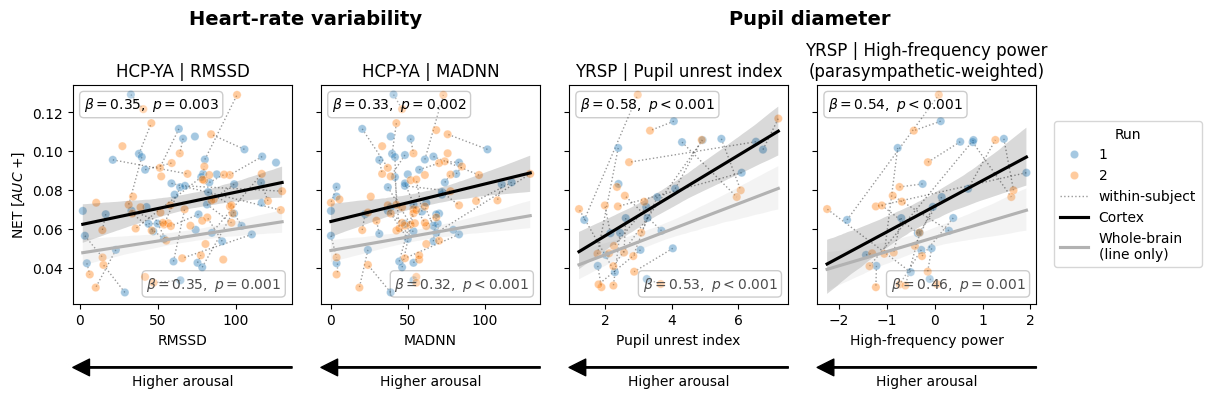

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(12, 5), sharey=True, constrained_layout=True,
                         gridspec_kw={"wspace": 0.08})

stat = "auc"
measure = "pearson"

for i, (dset, df, var) in enumerate([
    ("HCP-YA", physio_ya_hrv.loc[physio_ya_hrv["hrv_rmssd_qc"] == True, ["NET", "hrv_rmssd"]], "hrv_rmssd"), 
    ("HCP-YA", physio_ya_hrv.loc[physio_ya_hrv["hrv_madnn_qc"] == True, ["NET", "hrv_madnn"]], "hrv_madnn"), 
    ("YRSP", physio_yrsp_pui.loc[physio_yrsp_pui["qc"] == True, ["NET", "pui"]], "pui"),
    ("YRSP", physio_yrsp_pui.loc[physio_yrsp_pui["qc"] == True, ["NET", "hf_p"]], "hf_p")]):
            
    ax = axes[i]
    ax.set_box_aspect(1)
    
    # scatter points for cortex only
    parc = parc_cx
    sn.scatterplot(
        df.loc[parc, measure, stat, :, :, :].reset_index(),
        y="NET", 
        x=var, 
        hue="run", 
        alpha=0.4, ax=ax, palette="tab10",
    )
    for ii, sub in enumerate(df.index.get_level_values("sub").unique()):
        df_sub = df.loc[parc, measure, stat, sub, :, :].reset_index()
        ax.plot(
            df_sub[var], 
            df_sub["NET"], 
            color="k", 
            alpha=0.4,
            linewidth=1,
            linestyle=":",
            zorder=-10,
            label="within-subject" if ii==0 else ""
        )
    
    # regression line and annotation for cortex and whole-brain
    for parc in [parc_cx, parc_wb]:
        
        # regression line
        sn.regplot(
            df.loc[parc, measure, stat, :, :, :], 
            y="NET", 
            x=var, 
            scatter=False, 
            ax=ax, 
            color="k" if not "Subcortical" in parc else "0.7",
            label="Cortex" if not "Subcortical" in parc else "Whole-brain\n(line only)"
        )
        
        # annotation
        beta = res_physio.loc[(dset, var, parc), "beta"]
        p = res_physio.loc[(dset, var, parc), "p"]
        p = "< 0.001" if p < 0.001 else f"= {p:.3f}"
        ax.annotate(
            f"$\\beta = {beta:.2f},\ p {p}$",
            xy=(0.05, 0.95) if not "Subcortical" in parc else (0.95, 0.05),
            xycoords="axes fraction",
            ha="left" if not "Subcortical" in parc else "right",
            va="top" if not "Subcortical" in parc else "bottom",
            fontsize=10,
            color="k" if not "Subcortical" in parc else "0.3",
            bbox=dict(facecolor="white", alpha=0.2, boxstyle="round,pad=0.3")
        )

    # labels
    ax.set_title(f"{dset} | {MEASURES_NICE[var]}")
    ax.set_xlabel(MEASURES_NICE[var].split("\n")[0])
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel("NET $[AUC_\t{+}]$")
        
    # arousal arrow
    ax_arrow = ax.inset_axes((0, -0.32, 1, 0.3))
    ax_arrow.set_axis_off()
    ax_arrow.annotate(
        "",
        xy=(0, 0.1),
        xytext=(1, 0.1),
        arrowprops=dict(color="k", width=1),
    )
    ax_arrow.annotate(
        "Higher arousal",
        xy=(0.5, 0),
        ha="center",
        va="top",
    )
    
# legend
axes[3].legend(*axes[1].get_legend_handles_labels(), loc="center left", bbox_to_anchor=(1.05, 0.5), title="Run")
for ax in axes[[0,1,2]]:
    ax.legend().remove() 

fig.text(0.25, 0.84, "Heart-rate variability", fontweight="bold", fontsize=14, ha="center")
fig.text(0.67, 0.84, "Pupil diameter", fontweight="bold", fontsize=14, ha="center")

fig.savefig(wd / "plots" / "physio" / f"physiooverview_parc-{parc_cx}.pdf", bbox_inches="tight")